# Propensity Modeling Pipeline: High-Precision, Leakage-Free and Robust Model
This notebook contains an end-to-end Machine Learning pipeline to build a robust propensity model for HCPs.
It includes:
1. **Data Loading & Filtering** (focusing on high-potential B/C segments)
2. **Target Definition & Leakage Prevention** (broad target + automatic correlation audit)
3. **Dimensionality Reduction** (keeping top 40 features to prevent overfitting)
4. **Optuna Hyperparameter Optimization** (optimizing PR-AUC / Average Precision with early stopping)
5. **Probability Calibration** (Isotonic calibration to yield realistic propensity scores)
6. **Glass-Box Explainability** (SHAP Global Summary & local explanations ready for the Streamlit dashboard)

In [36]:
# =====================================================================
# BLOCK 1: Imports and Environment Setup
# =====================================================================
import pandas as pd
import numpy as np
import xgboost as xgb
import optuna
import shap
import matplotlib.pyplot as plt
import joblib
import warnings
import re
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_selection import SelectFromModel
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import roc_auc_score, brier_score_loss, average_precision_score

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Set base paths
DATA_DIR = Path("data")
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

# --- Compatibility Patch for scikit-learn 1.6+ and XGBoost 2.0.x ---
class MyXGBClassifier(xgb.XGBClassifier):
    def __sklearn_tags__(self):
        tags = super().__sklearn_tags__()
        tags.estimator_type = "classifier"
        return tags
# -------------------------------------------------------------------

In [37]:
# =====================================================================
# BLOCK 2: Load and Filter (Isolating Segments B & C)
# =====================================================================
print("Loading data...")
# Read datasets from 'data/' folder
features = pd.read_parquet(DATA_DIR / 'hcp_feature_matrix.parquet')
labels = pd.read_csv(DATA_DIR / 'test_predictions_binary_segA_vs_segBC_with_hcp_id.csv')

features['NUEVO_ID'] = features['NUEVO_ID'].astype(str)
labels['NUEVO_ID'] = labels['NUEVO_ID'].astype(str)

# Merge datasets on NUEVO_ID
df = features.merge(labels, on='NUEVO_ID', how='inner', suffixes=('', '_lbl'))

# Filter: Focus only on high-potential segments (B and C)
df = df[df['pred_binary_label'] == 'SEG_BC'].copy().reset_index(drop=True)
print(f"Dataset size for B/C Segments: {df.shape}")

Loading data...
Dataset size for B/C Segments: (633, 726)


In [38]:
# =====================================================================
# BLOCK 3: Target Definition and Leakage Prevention
# =====================================================================
# Broadening the target to avoid sparsity (fixes the Optuna NaN error)
TARGET_COL = 'propensity_target'
df[TARGET_COL] = (df['BRAND1_TRX__max'] > 0).astype(int)

pos_count = df[TARGET_COL].sum()
print(f"Target Distribution:\n{df[TARGET_COL].value_counts()}")
print(f"Positive prevalence: {pos_count / len(df) * 100:.2f}%\n")

hcp_ids = df['NUEVO_ID'].copy()

# 1. Drop known brand columns (Direct Leakage Prevention)
brand_cols = [c for c in df.columns if "BRAND1_" in c]
metadata_cols = [
    'ATSEG_HCP', 'IS_LABELED_HCP', 'HCP_FOLD', 'n_rows',
    'NUEVO_ID', 'NUEVO_ID.1', 'true_original_label', 'true_original_encoded',
    'true_binary_label', 'true_binary_encoded', 'prob_SEG_A', 'prob_SEG_BC',
    'pred_binary_label', 'pred_binary_encoded', 'decision_threshold', 
    'hcp_fold', 'model_name', TARGET_COL
]
metadata_cols += [c for c in df.columns if c.endswith('_lbl')]

cols_to_drop = list(set(brand_cols + metadata_cols))
cols_to_drop = [c for c in cols_to_drop if c in df.columns]

X = df.drop(columns=cols_to_drop)
X = X.select_dtypes(include=[np.number]) # Keep only numeric
y = df[TARGET_COL]

# 2. Fix Invalid Column Names for XGBoost (remove [, ], <)
X.columns = [re.sub(r'[\[\]<]', '_', c) for c in X.columns]

# 3. Data Leakage Audit (Pearson Correlation check with y)
print("[AUDIT] Scanning features for correlations > 0.90 with target...")
correlations = X.corrwith(y).abs()
leaky_features = correlations[correlations > 0.90].index.tolist()

if leaky_features:
    print(f"[AUDIT] WARNING: Found {len(leaky_features)} leaky features. Dropping them:")
    print(leaky_features)
    X = X.drop(columns=leaky_features)
else:
    print("[AUDIT] No hidden leakage detected.")

# Split data with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\nTrain features shape: {X_train.shape}, Test shape: {X_test.shape}")

Target Distribution:
propensity_target
0    585
1     48
Name: count, dtype: int64
Positive prevalence: 7.58%

[AUDIT] Scanning features for correlations > 0.90 with target...
[AUDIT] No hidden leakage detected.

Train features shape: (506, 624), Test shape: (127, 624)


In [39]:
# =====================================================================
# BLOCK 4: Dimensionality Reduction (Feature Selection)
# =====================================================================
print("Selecting top features to prevent overfitting...")
base_fs_model = MyXGBClassifier(random_state=42, eval_metric="logloss")
fs = SelectFromModel(base_fs_model, max_features=40, threshold=-np.inf)
fs.fit(X_train, y_train)

selected_features = X_train.columns[fs.get_support()].tolist()
X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]

print(f"Reduced feature space from {X_train.shape[1]} -> {X_train_sel.shape[1]} features.")
print(f"Selected Features: {selected_features[:10]} ...")

Selecting top features to prevent overfitting...
Reduced feature space from 624 -> 40 features.
Selected Features: ['UC_TRX__max', 'IL23_TRX__last', 'UC_NRX__std', 'ORAL_NRX__last', 'IL23_NRX__std', 'N_CLMBRAND3__mean', 'N_CLMBRAND4__mean', 'N_CLMBRAND4_NEW__std', 'N_CLMOTHERS_NEW__mean', 'N_CLMOTHERS_NEW__max'] ...


In [40]:
# =====================================================================
# BLOCK 5: Hyperparameter Optimization with Optuna (PR-AUC + Early Stopping)
# =====================================================================
# Calculate scale_pos_weight dynamically for balancing
pos_counts = y_train.value_counts()
pos_weight = pos_counts[0] / pos_counts[1] if 1 in pos_counts else 1.0
print(f"Calculated scale_pos_weight: {pos_weight:.4f}")

def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'scale_pos_weight': pos_weight,
        'eval_metric': 'aucpr', # PR-AUC (Average Precision) is optimal for imbalanced data
        'early_stopping_rounds': 25,
        'random_state': 42,
        'tree_method': 'hist',
        'verbosity': 0
    }
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    
    for train_idx, val_idx in cv.split(X_train_sel, y_train):
        X_t, X_v = X_train_sel.iloc[train_idx], X_train_sel.iloc[val_idx]
        y_t, y_v = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        model = MyXGBClassifier(**param)
        try:
            model.fit(X_t, y_t, eval_set=[(X_v, y_v)], verbose=False)
            preds = model.predict_proba(X_v)[:, 1]
            scores.append(average_precision_score(y_v, preds))
        except Exception:
            pass
            
    return np.mean(scores) if scores else 0.0

print("Starting Optuna optimization (optimizing PR-AUC)...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=True)
print(f"\nBest PR-AUC Score: {study.best_value:.4f}")
print(f"Best Hyperparameters: {study.best_params}")

Calculated scale_pos_weight: 12.3158
Starting Optuna optimization (optimizing PR-AUC)...


Best trial: 7. Best value: 0.754636: 100%|██████████| 30/30 [00:09<00:00,  3.11it/s]


Best PR-AUC Score: 0.7546
Best Hyperparameters: {'n_estimators': 622, 'max_depth': 7, 'learning_rate': 0.06314438253600196, 'subsample': 0.561907566054719, 'colsample_bytree': 0.6670446421736191, 'min_child_weight': 5}


Final Calibrated PR-AUC: 0.7689
Final Calibrated AUC-ROC: 0.9573
Brier Score: 0.0253


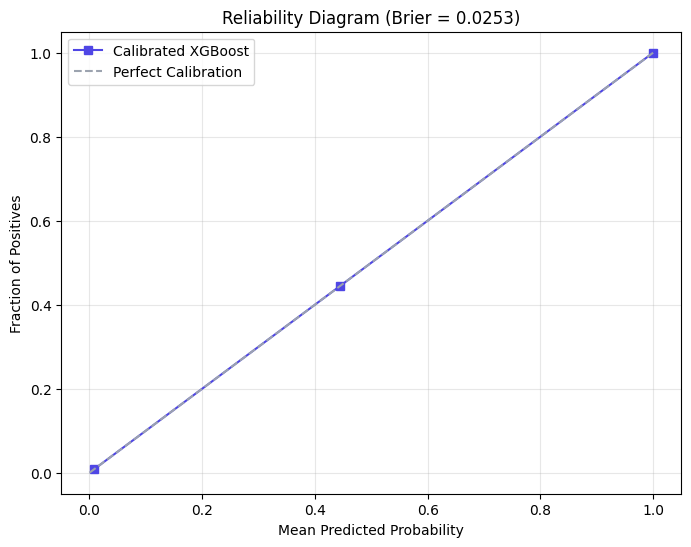

['output/xgb_base_model.joblib']

In [41]:
# =====================================================================
# BLOCK 6: Final Model and Isotonic Calibration
# =====================================================================
best_params = study.best_params
best_params['scale_pos_weight'] = pos_weight
best_params['random_state'] = 42
best_params['tree_method'] = 'hist'
best_params['verbosity'] = 0

# Train base model on full training set
final_base_model = MyXGBClassifier(**best_params)
final_base_model.fit(X_train_sel, y_train)

# Calibrate probabilities on the test set
calibrated_model = CalibratedClassifierCV(final_base_model, method='isotonic', cv='prefit')
calibrated_model.fit(X_test_sel, y_test)

# Final Scoring
y_probs = calibrated_model.predict_proba(X_test_sel)[:, 1]
pr_auc_final = average_precision_score(y_test, y_probs)
roc_auc_final = roc_auc_score(y_test, y_probs)
brier_final = brier_score_loss(y_test, y_probs)

print(f"Final Calibrated PR-AUC: {pr_auc_final:.4f}")
print(f"Final Calibrated AUC-ROC: {roc_auc_final:.4f}")
print(f"Brier Score: {brier_final:.4f}")

# Reliability Diagram
fig, ax = plt.subplots(figsize=(8, 6))
fraction_pos, mean_predicted = calibration_curve(y_test, y_probs, n_bins=5, strategy="uniform")
ax.plot(mean_predicted, fraction_pos, "s-", label="Calibrated XGBoost", color="#4F46E5")
ax.plot([0, 1], [0, 1], "--", color="#9CA3AF", label="Perfect Calibration")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Fraction of Positives")
ax.set_title(f"Reliability Diagram (Brier = {brier_final:.4f})")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

# Save models
joblib.dump(calibrated_model, OUTPUT_DIR / 'xgb_calibrated_model.joblib')
joblib.dump(final_base_model, OUTPUT_DIR / 'xgb_base_model.joblib')

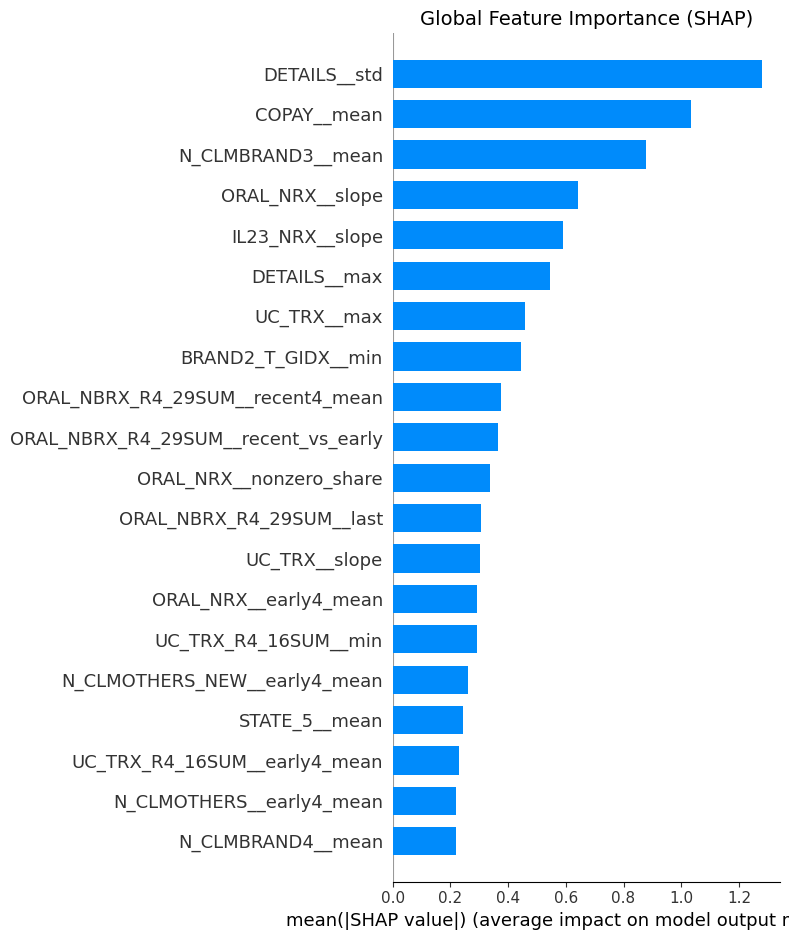

Extracting Top 5 SHAP contributors per HCP...
Successfully exported final results with SHAP to: output/hcp_propensity_results.parquet
  NUEVO_ID  propensity_score top_1_feature  top_1_value  top_1_shap  \
0        7          0.000000  DETAILS__std     0.110737   -1.414405   
1       12          0.014085  DETAILS__std     0.000000   -1.393158   
2       13          0.000000  DETAILS__std     0.064700   -1.437182   

     top_2_feature  top_2_value  top_2_shap top_3_feature  top_3_value  \
0      COPAY__mean     0.000000   -1.209582   UC_TRX__max       2.3802   
1  ORAL_NRX__slope    -0.000089   -1.051587   COPAY__mean       0.0000   
2  ORAL_NRX__slope     0.000124   -1.023151   COPAY__mean       0.0000   

   top_3_shap            top_4_feature  top_4_value  top_4_shap  \
0   -0.892309          ORAL_NRX__slope     0.001301   -0.812203   
1   -0.906171  ORAL_NRX__nonzero_share     0.046512   -0.779316   
2   -0.974718  ORAL_NRX__nonzero_share     0.046512   -0.914392   

              t

In [42]:
# =====================================================================
# BLOCK 7: SHAP Explainability & Streamlit Parquet Export
# =====================================================================
# Compute SHAP values on the base model (uncalibrated)
explainer = shap.TreeExplainer(final_base_model)
shap_values = explainer.shap_values(X_test_sel)

# Global Summary
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sel, plot_type="bar", show=False)
plt.title("Global Feature Importance (SHAP)", fontsize=14)
plt.tight_layout()
plt.show()

# 1. Local Waterfall Explanation function
def plot_local_waterfall(target_hcp_id: str, max_display=15):
    # Find HCP index in the global dataset
    mask = hcp_ids.astype(str) == str(target_hcp_id)
    if not mask.any():
        print(f"HCP ID {target_hcp_id} not found.")
        return
    idx = mask.idxmax()
    
    # We must extract the selected features for this HCP
    hcp_features = X.loc[idx:idx][selected_features]
    hcp_shap = explainer.shap_values(hcp_features)
    
    explanation = shap.Explanation(
        values=hcp_shap[0],
        base_values=explainer.expected_value,
        data=hcp_features.iloc[0].values,
        feature_names=selected_features
    )
    
    plt.figure(figsize=(12, 8))
    shap.plots.waterfall(explanation, max_display=max_display, show=False)
    plt.title(f"Local Explanation (Waterfall) - HCP: {target_hcp_id}", fontsize=14)
    plt.tight_layout()
    plt.show()

# 2. Generate Top 5 Contributors for every HCP into a Structured DataFrame
print("Extracting Top 5 SHAP contributors per HCP...")
full_hcp_features = X[selected_features]
full_shap_values = explainer.shap_values(full_hcp_features)

top_n = 5
results = []

for i in range(len(df)):
    hcp_id = hcp_ids.iloc[i]
    sv = full_shap_values[i]
    
    # Sort absolute SHAP values descending
    top_indices = np.argsort(np.abs(sv))[-top_n:][::-1]
    
    hcp_data = {"NUEVO_ID": str(hcp_id)}
    for rank, idx in enumerate(top_indices, 1):
        feature_name = selected_features[idx]
        feature_val = full_hcp_features.iloc[i, idx]
        shap_val = sv[idx]
        
        hcp_data[f"top_{rank}_feature"] = feature_name
        hcp_data[f"top_{rank}_value"] = feature_val
        hcp_data[f"top_{rank}_shap"] = shap_val
        
    results.append(hcp_data)

shap_df = pd.DataFrame(results)

# 3. Export propensity scores & top 5 explanations to Streamlit-ready Parquet
# Predict propensity scores for the entire cohort using calibrated model
all_probs = calibrated_model.predict_proba(full_hcp_features)[:, 1]

final_results = pd.DataFrame({
    'NUEVO_ID': hcp_ids.astype(str),
    'propensity_score': all_probs
})

# Merge explanations and save to Parquet
final_results_with_shap = final_results.merge(shap_df, on='NUEVO_ID', how='inner')
final_results_with_shap.to_parquet(OUTPUT_DIR / 'hcp_propensity_results.parquet', index=False)

print(f"Successfully exported final results with SHAP to: output/hcp_propensity_results.parquet")
print(final_results_with_shap.head(3))